# Virágfelismerés – Modell tanítása és összehasonlítása

Ebben a notebookban több neurális háló modellt hozok létre a virágképek osztályozására.
A cél annak vizsgálata, hogy különböző architektúrák és paraméterek hogyan befolyásolják a modell teljesítményét.

## CRISP-DM – Modellezés

A CRISP-DM módszertan következő lépése a modellezés.

Ebben a fázisban különböző neurális háló architektúrákat és paramétereket vizsgálunk annak érdekében, hogy megtaláljuk a legjobban teljesítő modellt.

A modell tanítása során az alábbi lépéseket hajtjuk végre:

- a képadatok betöltése a tanító és validációs halmazból
- több neurális háló architektúra létrehozása
- a modellek tanítása különböző paraméterekkel
- a modellek teljesítményének összehasonlítása
- a legjobb modell kiválasztása

## Vizsgált modellek

1. Egyszerű konvolúciós neurális háló (CNN)
2. CNN dropout réteggel a túlilleszkedés csökkentése érdekében

A két modell teljesítményét a validációs pontosság alapján hasonlítjuk össze.

In [17]:
import os
import tarfile
import urllib.request

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix

# Projektgyökér meghatározása helyi Jupyter és Colab futtatáshoz.
cwd = Path.cwd()
possible_roots = [
    cwd,
    cwd.parent,
    Path("/content/adatelemzesi-projekt"),
    Path("/content/drive/MyDrive/adatelemzesi-projekt"),
]

PROJECT_ROOT = None
for candidate in possible_roots:
    if (candidate / "notebooks").exists() and (candidate / "README.md").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    if cwd.name == "notebooks" and (cwd.parent / "README.md").exists():
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOKS_DIR.exists() and Path.cwd() != NOTEBOOKS_DIR:
    os.chdir(NOTEBOOKS_DIR)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = DATA_RAW_DIR / "flower_photos"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

for directory in [DATA_RAW_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Automatikus adathalmaz-letöltés, ha hiányzik (Colabban nem kell Kaggle token).
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
if not DATASET_PATH.exists():
    archive_path = DATA_RAW_DIR / "flower_photos.tgz"
    print(f"Az adathalmaz nem található itt {DATASET_PATH}. letöltés innen: {DATASET_URL}")
    urllib.request.urlretrieve(DATASET_URL, archive_path)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_RAW_DIR)
    archive_path.unlink(missing_ok=True)
    print(f"Adathalmaz kicsomagolva ide: {DATASET_PATH}")
else:
    print(f"Adathalmaz megtalálva: {DATASET_PATH}")

print(f"Projekt gyökérmappa: {PROJECT_ROOT}")


## Adathalmaz betöltése

In [18]:
dataset_path = DATASET_PATH


In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [20]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [21]:
class_names = train_ds.class_names

hungarian_labels = {
    "daisy": "százszorszép",
    "dandelion": "pitypang",
    "roses": "rózsa",
    "sunflowers": "napraforgó",
    "tulips": "tulipán"
}

print("Kategóriák:", class_names)

Kategóriák: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Adathalmaz optimalizálás

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Modell 1 – Egyszerű CNN

In [23]:
model1 = tf.keras.Sequential([
    tf.keras.Input(shape=(180,180,3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(len(class_names))
])

In [24]:
model1.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [25]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

history1_df = pd.DataFrame(history1.history)
history1_df.insert(0, "epoch", range(1, len(history1_df) + 1))
history1_path = TABLES_DIR / "03_history_model1.csv"
history1_df.to_csv(history1_path, index=False)
print(f"Táblázat mentve: {history1_path}")


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.3515 - loss: 1.5727 - val_accuracy: 0.4877 - val_loss: 1.2013
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.5279 - loss: 1.1371 - val_accuracy: 0.5613 - val_loss: 1.0764
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.6039 - loss: 0.9965 - val_accuracy: 0.5954 - val_loss: 1.0350
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7013 - loss: 0.8083 - val_accuracy: 0.5886 - val_loss: 1.0224
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7766 - loss: 0.6085 - val_accuracy: 0.6322 - val_loss: 1.0321
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.8614 - loss: 0.3974 - val_accuracy: 0.6417 - val_loss: 1.1284
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9166 - loss: 0.2607 - val_accuracy: 0.6022 - val_loss: 1.3610
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9605 - loss: 0.1432 - val_accuracy: 0.6199 - 

# Modell 2 – CNN Dropout réteggel

In [26]:
model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(180,180,3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,padding="same",activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names))
])

In [27]:
model2.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [28]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

history2_df = pd.DataFrame(history2.history)
history2_df.insert(0, "epoch", range(1, len(history2_df) + 1))
history2_path = TABLES_DIR / "03_history_model2.csv"
history2_df.to_csv(history2_path, index=False)
print(f"Táblázat mentve: {history2_path}")


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.3934 - loss: 1.4310 - val_accuracy: 0.5354 - val_loss: 1.0919
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.5647 - loss: 1.0685 - val_accuracy: 0.5831 - val_loss: 1.0143
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6284 - loss: 0.9318 - val_accuracy: 0.6444 - val_loss: 0.9401
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.6999 - loss: 0.7968 - val_accuracy: 0.6335 - val_loss: 0.8990
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.7623 - loss: 0.6442 - val_accuracy: 0.6662 - val_loss: 0.8909
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.8082 - loss: 0.5049 - val_accuracy: 0.6635 - val_loss: 0.9159
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8692 - loss: 0.3581 - val_accuracy: 0.6444 - val_loss: 1.1059
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9128 - loss: 0.2547 - val_accuracy: 0.6485 - 

## Modell teljesítmény összehasonlítása

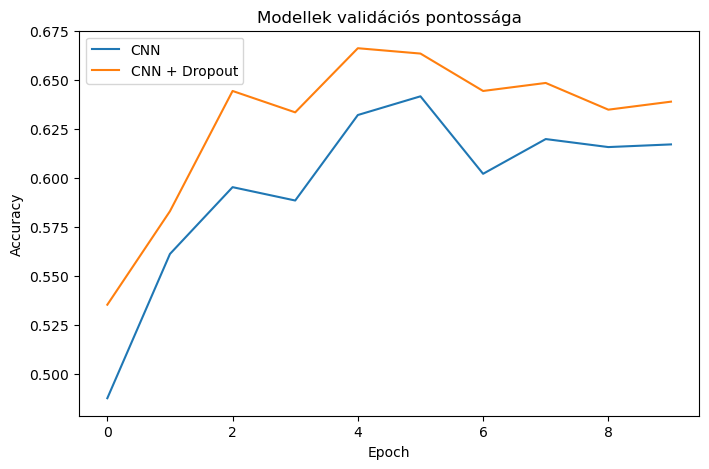

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history1.history["val_accuracy"], label="CNN")
plt.plot(history2.history["val_accuracy"], label="CNN + Dropout")

plt.title("Modellek validációs pontossága")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()
val_accuracy_path = FIGURES_DIR / "03_validation_accuracy_comparison.png"
plt.savefig(val_accuracy_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {val_accuracy_path}")
plt.show()


## Konfúziós mátrix (legjobb modell)

In [30]:
best_model = model2

In [31]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images)
    preds = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [32]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"valodi_{name}" for name in class_names],
    columns=[f"predikcio_{name}" for name in class_names]
)
cm_path = TABLES_DIR / "03_confusion_matrix.csv"
cm_df.to_csv(cm_path, index=True)
print(f"Táblázat mentve: {cm_path}")


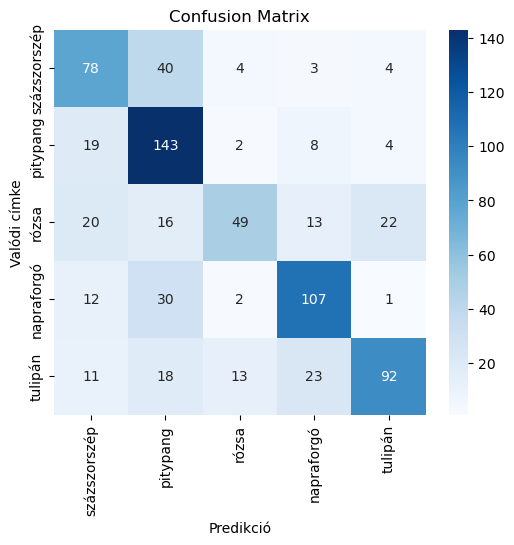

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[hungarian_labels[name] for name in class_names],
    yticklabels=[hungarian_labels[name] for name in class_names]
)

plt.xlabel("Predikció")
plt.ylabel("Valódi címke")
plt.title("Konfúziós mátrix")
confusion_matrix_fig_path = FIGURES_DIR / "03_confusion_matrix.png"
plt.savefig(confusion_matrix_fig_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {confusion_matrix_fig_path}")
plt.show()


## Modell teljesítmény értékelése

Az eredmények alapján a dropout réteget tartalmazó modell stabilabb validációs pontosságot mutatott.
Ez arra utal, hogy a dropout segít csökkenteni a túlilleszkedést és javítja a modell általánosítási képességét.

In [34]:
import os

os.makedirs("../outputs/models", exist_ok=True)

model2.save("../outputs/models/flower_classifier.keras")

print("Legjobb modell elmentve.")


Legjobb modell elmentve.
